<a href="https://colab.research.google.com/github/silviobear/COMPUTER_VISION_DEEPFAKE/blob/main/computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Github


In [2]:
import os
from getpass import getpass

# 1. Torniamo alla cartella principale e puliamo eventuali cloni a metà
%cd /content
!rm -rf COMPUTER_VISION_DEEPFAKE

# 2. Inserisci i tuoi dati (SOSTITUISCI IL TOKEN!)
GITHUB_TOKEN = getpass("Token: ")
GITHUB_USER = "silviobear"
REPO_NAME = "COMPUTER_VISION_DEEPFAKE"

# Costruiamo l'URL sicuro
clone_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git"

# 3. Cloniamo il repository bypassando la richiesta di password
!git clone {clone_url}

# 4. Entriamo nella cartella appena scaricata
%cd {REPO_NAME}

# 5. Riapplichiamo il path per gli import che avevamo sistemato prima
import sys
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print("✅ Repository clonato e pronto all'uso!")

/content
Token: ··········
Cloning into 'COMPUTER_VISION_DEEPFAKE'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 50 (delta 22), reused 29 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 25.82 KiB | 12.91 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/COMPUTER_VISION_DEEPFAKE
✅ Repository clonato e pronto all'uso!


In [3]:
# 1. Spostati nella cartella dove hai clonato il repo
%cd /content/COMPUTER_VISION_DEEPFAKE

# 2. Forza Colab a scaricare le ultime modifiche fatte da VS Code
!git pull origin main

# 3. Aggiungi la cartella al "path" di Python per abilitare l'import
import sys
import os

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

# 4. Ricarica i moduli per essere sicuri che veda le modifiche recenti
import importlib
import data
import utils
import network
import train

importlib.reload(data)
importlib.reload(utils)
importlib.reload(network)
importlib.reload(train)

print("✅ File rilevati e caricati correttamente!")

# 5. Importiamo tutto ciò che serve per la pipeline dell'esame
from data import DeepfakeJPEGAIDataset, base_transform
from utils import compute_2d_dct
from network import get_model
from train import train_model

print("✅ Moduli pronti all'uso:")
print("   - data: DeepfakeJPEGAIDataset")
print("   - utils: compute_2d_dct")
print("   - network: get_model")
print("   - train: train_model")

/content/COMPUTER_VISION_DEEPFAKE
From https://github.com/silviobear/COMPUTER_VISION_DEEPFAKE
 * branch            main       -> FETCH_HEAD
Already up to date.
✅ File rilevati e caricati correttamente!
✅ Moduli pronti all'uso:
   - data: DeepfakeJPEGAIDataset
   - utils: compute_2d_dct
   - network: get_model
   - train: train_model


# Imports

# Globals

# Utils


In [ ]:
from utils import compute_2d_dct
# Quando avrai caricato l'immagine dal dataset...
# spettro_frequenze = compute_2d_dct(mia_immagine)

# Data

## JPEG AI – Compressione dataset (Fase 1)

In [6]:
# --- Setup JPEG AI reference software (lento: ~20-40 min, una volta per sessione) ---
# ⚠️ Questa cella gira SOLO su Google Colab (Linux+GPU). In locale su Windows i
#    comandi wget/apt-get/make/conda non esistono: NON eseguirla qui.
try:
    import google.colab  # noqa: F401
except ImportError:
    raise RuntimeError(
        "Questa sezione va eseguita SOLO su Google Colab, non in locale. "
        "In locale usa VS Code solo per modificare i .py e fare push."
    )

import os

# 1. Miniconda in una cartella dedicata: NON sostituisce il Python di Colab (torch resta intatto)
if not os.path.exists('/content/miniconda/bin/conda'):
    !wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /content/miniconda.sh
    !bash /content/miniconda.sh -b -p /content/miniconda
# Mette conda sul PATH per questa sessione (serve anche a 'conda run' in data.py)
os.environ['PATH'] = '/content/miniconda/bin:' + os.environ['PATH']
# Evita che il Python dell'env conda peschi i pacchetti di Colab (causa conflitti in build)
os.environ.pop('PYTHONPATH', None)
!conda --version

# 2. Accetta i Terms of Service dei canali conda (le versioni recenti di conda lo richiedono,
#    altrimenti 'conda create' fallisce in modo silenzioso e l'env jpeg_ai_vm non viene creato)
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

# 3. Pacchetti di sistema + git-lfs
!apt-get -qq install -y git-lfs doxygen graphviz
!git lfs install

# 4. Clone del reference software (idempotente)
%cd /content
if not os.path.isdir('/content/jpeg-ai-reference-software'):
    !git clone https://gitlab.com/wg1/jpeg-ai/jpeg-ai-reference-software.git
%cd /content/jpeg-ai-reference-software

# 5. Scarica i modelli/pesi versionati con LFS
!git lfs fetch
!git lfs checkout

# 6. Crea env conda 'jpeg_ai_vm' (python 3.7) + installa requirements + builda le librerie C++
#    (make setup_env esegue gia' anche build_test_libs.sh alla fine)
!make setup_env

# 7. Verifica che l'env esista e che i moduli C++ siano stati compilati
print('\n--- Verifica env ---')
!conda env list | grep jpeg_ai_vm || echo "❌ env jpeg_ai_vm NON creato"
!conda run -n jpeg_ai_vm python -c "import pybind11, torch; print('pybind11 e torch OK nel env')" || echo "❌ pacchetti env mancanti"

print('✅ Cella di setup terminata: controlla sopra che env jpeg_ai_vm esista e che la build non abbia dato errori.')

PREFIX=/content/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /content/miniconda
conda 26.3.2
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Selecting previously unselected package libllvm14:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../0-libllvm14_1%3a14.0.0-1ubuntu1.1_amd64.deb ...
Unpacking libllvm14:amd64 (1:14.0.0-1ubuntu1.1) ...
Selecting previously unselected package libclang-cpp1

## Dataset reale: FaceForensics++ (c23)

Dataset deepfake "ufficiale" (face manipulation). Usiamo i **frame già estratti** dal dataset Kaggle `fatimahirshad/faceforensics-extracted-dataset-c23`.

- **real** = cartella `Original`
- **fake** = cartella `Deepfakes` (il face-swap classico; ignoriamo gli altri metodi per restare leggeri)

Le celle sintetiche qui sopra (rumore casuale) restano solo come *smoke-test*: il dataset vero è questo.

In [26]:
# --- Download FaceForensics++ (frame estratti, c23) da Kaggle ---
import os
from getpass import getpass

FF_DIR = "/content/ff"

if not os.path.isdir(f"{FF_DIR}/FF++C32-Frames"):
    # Token Kaggle: NON incollarlo nel codice. Usa getpass (o i Secrets di Colab).
    if "KAGGLE_API_TOKEN" not in os.environ:
        token = getpass("Kaggle API token (KGAT_...): ").strip()
        os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
        with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
            f.write(token)
        os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)
        os.environ["KAGGLE_API_TOKEN"] = token
    !pip -q install -U kaggle
    !kaggle datasets download -d fatimahirshad/faceforensics-extracted-dataset-c23 -p {FF_DIR} --unzip
else:
    print("Dataset già presente, salto il download.")

!ls {FF_DIR}/FF++C32-Frames

Kaggle API token (KGAT_...): ··········
Dataset URL: https://www.kaggle.com/datasets/fatimahirshad/faceforensics-extracted-dataset-c23
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 3.78G/3.78G [00:48<00:00, 83.0MB/s]

Deepfakes  Face2Face  FaceShifter  FaceSwap  NeuralTextures  Original


In [ ]:
# --- Prepara real_original/ e fake_original/ nella struttura del progetto ---
import importlib, data; importlib.reload(data)
from data import build_original_split

DATASET_PATH = "/content/drive/MyDrive/Deepfake_FF_Dataset"   # path UNICO usato anche dalla compressione
FF_FRAMES    = "/content/ff/FF++C32-Frames"

build_original_split(
    real_src=f"{FF_FRAMES}/Original",
    fake_src=f"{FF_FRAMES}/Deepfakes",   # 'Deepfakes' = face-swap classico
    dataset_path=DATASET_PATH,
    n_per_class=200,   # parti PICCOLO per validare la pipeline; poi scala a 500-800
)

In [7]:
# Compressione del dataset (chiama il wrapper definito in data.py)
import importlib, data
importlib.reload(data)
from data import compress_dataset_jpegai

DATASET_PATH = '/content/drive/MyDrive/Deepfake_Dataset'   # stesso path della cella di prep
JPEGAI_DIR   = '/content/jpeg-ai-reference-software'
BPP_LIST     = [0.12, 0.25, 0.50, 0.75]   # DEVONO combaciare con il target_bpp usato nel DataLoader
PROFILE      = 'base'                       # 'simple' | 'base' | 'high'

compress_dataset_jpegai(DATASET_PATH, BPP_LIST, JPEGAI_DIR, profile=PROFILE)

# Risultato: real_bpp0.12, fake_bpp0.12, ... su Drive.
# Caricale poi con: DeepfakeJPEGAIDataset(DATASET_PATH, target_bpp=0.12, ...)

=== Classe real: 2 immagini ===
  bpp=0.12 -> /content/drive/MyDrive/Deepfake_Dataset/real_bpp0.12
  bpp=0.25 -> /content/drive/MyDrive/Deepfake_Dataset/real_bpp0.25
  bpp=0.5 -> /content/drive/MyDrive/Deepfake_Dataset/real_bpp0.5
  bpp=0.75 -> /content/drive/MyDrive/Deepfake_Dataset/real_bpp0.75
=== Classe fake: 2 immagini ===
  bpp=0.12 -> /content/drive/MyDrive/Deepfake_Dataset/fake_bpp0.12
  bpp=0.25 -> /content/drive/MyDrive/Deepfake_Dataset/fake_bpp0.25
  bpp=0.5 -> /content/drive/MyDrive/Deepfake_Dataset/fake_bpp0.5
  bpp=0.75 -> /content/drive/MyDrive/Deepfake_Dataset/fake_bpp0.75
✅ Compressione completata.


# XceptionNet

In [13]:
!git clone -q https://github.com/HongguLiu/Deepfake-Detection.git
import sys; sys.path.append('/content/Deepfake-Detection')

# Apri il README del repo, copia il link Google Drive di FF++_c23.pth e incollalo qui:
!gdown --fuzzy "https://drive.google.com/file/d/1Zi66nWADRIgS8B01Doa1aUvZmH57bllP/view?usp=drive_link" -O /content/ffpp_c23.pth

fatal: destination path 'Deepfake-Detection' already exists and is not an empty directory.
Downloading...
From: https://drive.google.com/uc?id=1Zi66nWADRIgS8B01Doa1aUvZmH57bllP
To: /content/ffpp_c23.pth
100% 83.5M/83.5M [00:00<00:00, 182MB/s]


In [15]:
!git clone https://github.com/HongguLiu/Deepfake-Detection.git /content/Deepfake-Detection
!ls /content/Deepfake-Detection

Cloning into '/content/Deepfake-Detection'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 118 (delta 35), reused 25 (delta 25), pack-reused 73 (from 1)
Receiving objects: 100% (118/118), 129.92 MiB | 38.33 MiB/s, done.
Resolving deltas: 100% (54/54), done.
data_list		      LICENSE		test_CNN.py
dataset			      network		train_CNN.py
detect_from_video.py	      README.md		videos
download-FaceForensics_v3.py  requirements.txt


In [21]:
import sys, os, importlib, torch
REPO = '/content/Deepfake-Detection'
os.chdir(REPO)                                  # cwd = repo (doppia sicurezza per gli import)

open(os.path.join(REPO, 'network', '__init__.py'), 'a').close()
open(os.path.join(REPO, 'dataset', '__init__.py'), 'a').close()

sys.path = [p for p in sys.path if 'COMPUTER_VISION_DEEPFAKE' not in p]
for k in list(sys.modules):
    if k.split('.')[0] in ('network', 'dataset'):
        del sys.modules[k]
if REPO not in sys.path:
    sys.path.insert(0, REPO)

importlib.invalidate_caches()                   # <-- FA VEDERE i nuovi __init__.py
print("network/__init__.py:", os.path.exists(f'{REPO}/network/__init__.py'))
print("sys.path[0]:", sys.path[0])

# Import + costruzione + pesi
from network.models import model_selection
device = 'cuda' if torch.cuda.is_available() else 'cpu'
m = model_selection('xception', num_out_classes=2)
model = m[0] if isinstance(m, tuple) else m

ckpt = torch.load('/content/ffpp_c23.pth', map_location=device)
if hasattr(ckpt, 'forward'):
    model = ckpt
else:
    sd = ckpt.get('state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
    print(model.load_state_dict(sd, strict=False))
model = model.to(device).eval()
print("✅ Modello caricato")

network/__init__.py: True
sys.path[0]: /content/Deepfake-Detection
Using dropout 0.5
<All keys matched successfully>
✅ Modello caricato


In [29]:
import cv2, numpy as np
from PIL import Image
import torchvision.transforms as T

_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
xtf = T.Compose([T.Resize((299,299)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])

def crop_face(pil, scale=1.3):
    img = np.array(pil)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = _cascade.detectMultiScale(gray, 1.1, 5, minSize=(60, 60))
    if len(faces) == 0:
        return None
    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    cx, cy = x + w / 2.0, y + h / 2.0
    size = int(max(w, h) * scale)                 # box QUADRATO, scala FF++
    x1 = max(0, int(cx - size / 2)); y1 = max(0, int(cy - size / 2))
    x2 = min(pil.width, int(cx + size / 2)); y2 = min(pil.height, int(cy + size / 2))
    return pil.crop((x1, y1, x2, y2))

@torch.no_grad()
def predict(path):
    face = crop_face(Image.open(path).convert("RGB"))
    if face is None:
        return None
    logits = model(xtf(face).unsqueeze(0).to(device))
    return torch.softmax(logits, 1)[0].cpu().numpy()   # [p0, p1]

print("✅ Face-crop (OpenCV) e predict pronti")

✅ Face-crop (OpenCV) e predict pronti


In [31]:
import os
DATASET_PATH = "/content/drive/MyDrive/Deepfake_Dataset"
for cls in ['real','fake']:
    d = os.path.join(DATASET_PATH, f'{cls}_original')
    for f in sorted(os.listdir(d)):
        p = predict(os.path.join(d,f))
        print(f"{cls:4s} {f} -> {None if p is None else np.round(p,3)}")

real real_00000.png -> [0. 1.]
real real_00001.png -> [0. 1.]
fake fake_00000.png -> [0. 1.]
fake fake_00001.png -> [0. 1.]


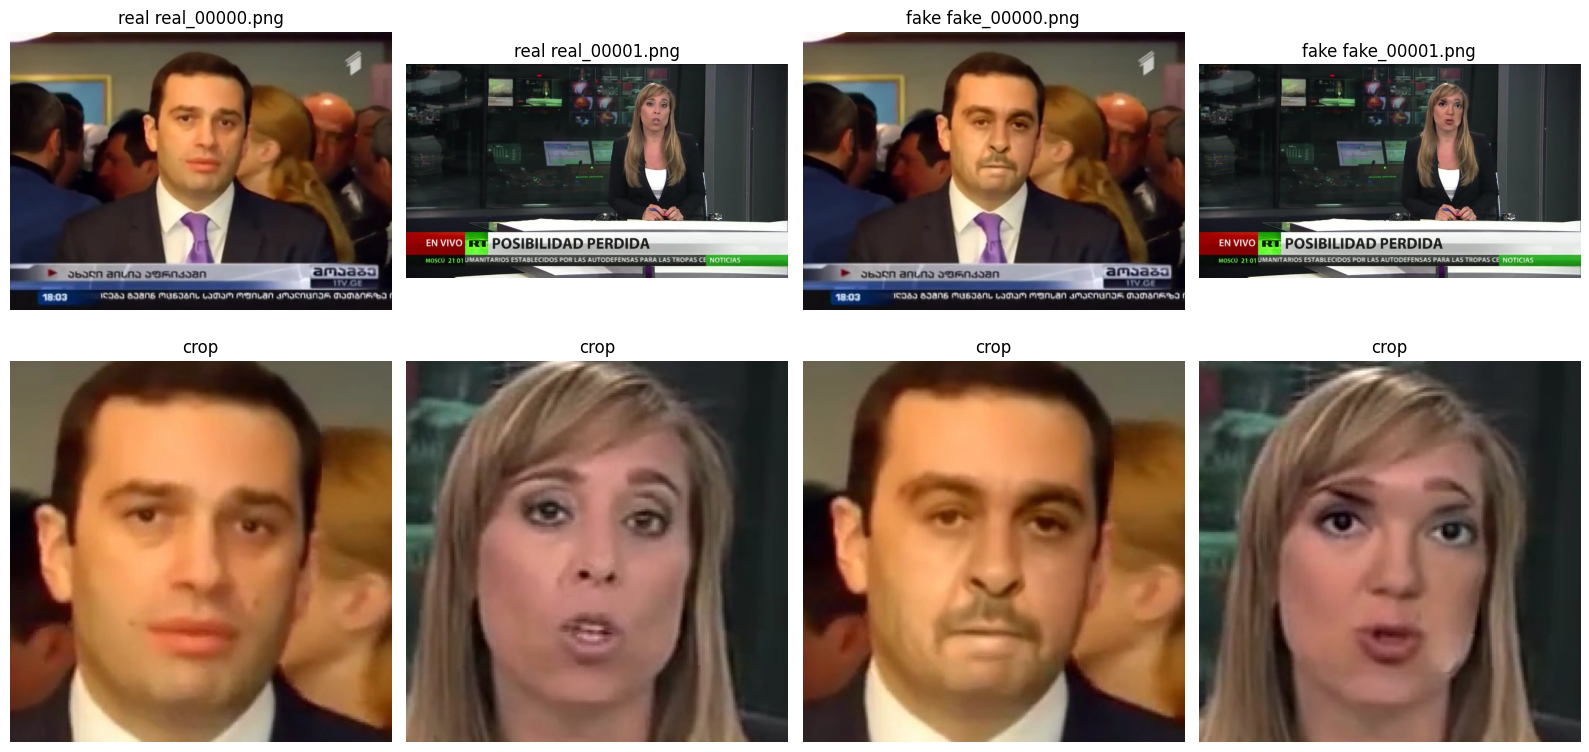

In [34]:
import matplotlib.pyplot as plt, os
from PIL import Image

DATASET_PATH = "/content/drive/MyDrive/Deepfake_Dataset"
paths = []
for cls in ['real', 'fake']:
    d = os.path.join(DATASET_PATH, f'{cls}_original')
    for f in sorted(os.listdir(d)):
        paths.append((cls, f, os.path.join(d, f)))

fig, axes = plt.subplots(2, len(paths), figsize=(4*len(paths), 8))
for j, (cls, name, p) in enumerate(paths):
    pil = Image.open(p).convert('RGB')
    face = crop_face(pil)
    axes[0, j].imshow(pil); axes[0, j].set_title(f'{cls} {name}'); axes[0, j].axis('off')
    if face is not None:
        axes[1, j].imshow(face)
    axes[1, j].set_title('crop' if face is not None else 'NO FACE'); axes[1, j].axis('off')
plt.tight_layout(); plt.show()

In [33]:
import os, random, numpy as np

FF = "/content/ff/FF++C32-Frames"
N = 100                      # immagini per classe (veloce, niente compressione)
FAKE_IDX = 1                 # convenzione scoperta: 0=real, 1=fake
rng = random.Random(0)

def sample(folder, n):
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    rng.shuffle(files)
    return files[:n]

tot_correct = tot_n = 0
for cls, folder, label in [("real", f"{FF}/Original", 0), ("fake", f"{FF}/Deepfakes", 1)]:
    correct = total = noface = 0
    for p in sample(folder, N):
        probs = predict(p)
        if probs is None:
            noface += 1; continue
        correct += int(int(np.argmax(probs)) == label)
        total += 1
    print(f"{cls}: acc={correct/total:.1%} su {total}  (volti non trovati: {noface})")
    tot_correct += correct; tot_n += total

print(f"\n▶ Accuratezza baseline complessiva: {tot_correct/tot_n:.1%} su {tot_n} immagini")

real: acc=2.0% su 98  (volti non trovati: 2)
fake: acc=99.0% su 100  (volti non trovati: 0)

▶ Accuratezza baseline complessiva: 51.0% su 198 immagini


In [32]:
import numpy as np
def fakeprobs(folder, n=40):
    xs = []
    for p in sample(folder, n):
        pr = predict(p)
        if pr is not None:
            xs.append(float(pr[1]))      # p(indice 1)
    return np.array(xs)

r = fakeprobs(f"{FF}/Original", 40)
f = fakeprobs(f"{FF}/Deepfakes", 40)
print(f"REAL  p(idx1): mean={r.mean():.2f}  min={r.min():.2f}  max={r.max():.2f}")
print(f"FAKE  p(idx1): mean={f.mean():.2f}  min={f.min():.2f}  max={f.max():.2f}")

REAL  p(idx1): mean=0.98  min=0.09  max=1.00
FAKE  p(idx1): mean=0.99  min=0.65  max=1.00


In [35]:
@torch.no_grad()
def predict_bgr(path):
    face = crop_face(Image.open(path).convert('RGB'))
    if face is None:
        return None
    arr = np.array(face)[:, :, ::-1]            # RGB -> BGR
    face_bgr = Image.fromarray(np.ascontiguousarray(arr))
    logits = model(xtf(face_bgr).unsqueeze(0).to(device))
    return torch.softmax(logits, 1)[0].cpu().numpy()

import numpy as np
def fakeprobs_bgr(folder, n=40):
    xs = [predict_bgr(p) for p in sample(folder, n)]
    return np.array([x[1] for x in xs if x is not None])

r = fakeprobs_bgr(f"{FF}/Original", 40)
f = fakeprobs_bgr(f"{FF}/Deepfakes", 40)
print(f"REAL  p(idx1): mean={r.mean():.2f}  min={r.min():.2f}  max={r.max():.2f}")
print(f"FAKE  p(idx1): mean={f.mean():.2f}  min={f.min():.2f}  max={f.max():.2f}")

REAL  p(idx1): mean=0.98  min=0.03  max=1.00
FAKE  p(idx1): mean=1.00  min=0.99  max=1.00


In [36]:
!pip -q install -U transformers
import torch, numpy as np
from transformers import pipeline
from PIL import Image

det = pipeline("image-classification",
               model="dima806/deepfake_vs_real_image_detection",
               device=0 if torch.cuda.is_available() else -1)

def hf_fake_prob(path):
    face = crop_face(Image.open(path).convert("RGB"))   # riusiamo il crop; se None, salta
    if face is None:
        return None
    d = {o['label'].lower(): o['score'] for o in det(face)}
    return d.get('fake')                                 # prob. classe 'Fake'

r = [hf_fake_prob(p) for p in sample(f"{FF}/Original", 40)]
f = [hf_fake_prob(p) for p in sample(f"{FF}/Deepfakes", 40)]
r = np.array([x for x in r if x is not None])
f = np.array([x for x in f if x is not None])
print(f"REAL  p(fake): mean={r.mean():.2f}  min={r.min():.2f}  max={r.max():.2f}")
print(f"FAKE  p(fake): mean={f.mean():.2f}  min={f.min():.2f}  max={f.max():.2f}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, which is not installed.
facenet-pytorch 2.6.0 requires torch<2.3.0,>=2.2.0, which is not installed.
facenet-pytorch 2.6.0 requires torchvision<0.18.0,>=0.17.0, which is not installed.
facenet-pytorch 2.6.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.5.0 which is incompatible.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

REAL  p(fake): mean=0.46  min=0.00  max=1.00
FAKE  p(fake): mean=0.46  min=0.00  max=1.00


# Veritas

In [39]:
from facenet_pytorch import MTCNN
import torch
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(image_size=64, margin=14, keep_all=False, post_process=False, device=device)
print("✅ MTCNN pronto")

# prova su un'immagine reale
p = sample(f"{FF}/Original", 1)[0]
face = mtcnn(Image.open(p).convert('RGB'))
if face is None:
    print("⚠️ nessun volto rilevato su questa immagine")
else:
    print("face shape:", tuple(face.shape), "| range:", float(face.min()), "-", float(face.max()))

✅ MTCNN pronto
face shape: (3, 64, 64) | range: 0.0 - 255.0


In [40]:
!kaggle kernels output sandeepkumargond01/deepfake -p /content/veritas
!ls -la /content/veritas

Output file downloaded to /content/veritas/best_veritas_model.pth
Kernel log downloaded to /content/veritas/deepfake.log 
total 9168
drwxr-xr-x 2 root root    4096 Jun 29 11:31 .
drwxr-xr-x 1 root root    4096 Jun 29 11:31 ..
-rw-r--r-- 1 root root 8504645 Jun 29 11:31 best_veritas_model.pth
-rw-r--r-- 1 root root  871897 Jun 29 11:31 deepfake.log


In [41]:
import torch, torch.nn as nn, torch.nn.functional as F
from collections import OrderedDict

class CWA(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(ch, ch//2, bias=False), nn.ReLU(),
                                nn.Linear(ch//2, ch, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.fc(self.gap(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1); self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1); self.bn2 = nn.BatchNorm2d(out_c)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride), nn.BatchNorm2d(out_c))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out)); out += self.shortcut(x)
        return F.relu(out)

class CompressionAwareHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.spatial = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2,2))
        self.cwa_spatial = CWA(128)
        self.wavelet = nn.Sequential(
            nn.Conv2d(9,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2,2))
        self.cwa_wavelet = CWA(64)
        self.align = nn.Conv2d(64,128,1)
        self.entry = nn.Sequential(nn.Conv2d(256,64,7,stride=2,padding=3), nn.BatchNorm2d(64), nn.ReLU(),
                                   nn.MaxPool2d(3,stride=2,padding=1))
        self.middle = nn.Sequential(ResBlock(64,128,2), ResBlock(128,256,2))
        self.exit = nn.Sequential(nn.Conv2d(256,128,1), nn.BatchNorm2d(128), nn.ReLU(),
                                  nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128,2))
    def forward(self, img, wav):
        s = self.cwa_spatial(self.spatial(img))
        w = self.cwa_wavelet(self.wavelet(wav))
        w = F.interpolate(self.align(w), size=s.shape[2:])
        return self.exit(self.middle(self.entry(torch.cat([s, w], dim=1))))

WEIGHTS = '/content/veritas/best_veritas_model.pth'   # <-- aggiusta se il path è diverso
vmodel = CompressionAwareHybrid().to(device)
sd = torch.load(WEIGHTS, map_location=device)
sd = OrderedDict((k[7:] if k.startswith('module.') else k, v) for k, v in sd.items())
print(vmodel.load_state_dict(sd))      # vogliamo <All keys matched>
vmodel.eval(); print("✅ Veritas caricato")

<All keys matched successfully>
✅ Veritas caricato


In [42]:
import pywt, numpy as np

@torch.no_grad()
def veritas_predict(path):
    face = mtcnn(Image.open(path).convert('RGB'))     # [3,64,64] in [0,255]
    if face is None: return None
    face = face.cpu()
    fnp = face.permute(1, 2, 0).numpy()
    wav = []
    for c in range(3):
        LL, (LH, HL, HH) = pywt.dwt2(fnp[:, :, c], 'db2')
        wav += [LH, HL, HH]
    wav_t  = torch.tensor(np.stack(wav, 0)).float().unsqueeze(0).to(device)
    face_t = face.float().unsqueeze(0).to(device)     # NIENTE normalizzazione (come training)
    return torch.softmax(vmodel(face_t, wav_t), 1)[0].cpu().numpy()   # [p_real, p_fake]

tot_c = tot_n = 0
for cls, folder, label in [("real", f"{FF}/Original", 0), ("fake", f"{FF}/Deepfakes", 1)]:
    c = t = nf = 0
    for p in sample(folder, 60):
        pr = veritas_predict(p)
        if pr is None: nf += 1; continue
        c += int(int(np.argmax(pr)) == label); t += 1
    print(f"{cls}: acc={c/t:.1%} su {t}  (no-face {nf})")
    tot_c += c; tot_n += t
print(f"\n▶ Accuratezza baseline Veritas: {tot_c/tot_n:.1%} su {tot_n}")

real: acc=5.0% su 60  (no-face 0)
fake: acc=100.0% su 60  (no-face 0)

▶ Accuratezza baseline Veritas: 52.5% su 120


In [43]:
import numpy as np
from sklearn.metrics import roc_auc_score

scores, labels = [], []
for cls, folder, label in [("real", f"{FF}/Original", 0), ("fake", f"{FF}/Deepfakes", 1)]:
    for p in sample(folder, 100):
        pr = veritas_predict(p)
        if pr is None: continue
        scores.append(float(pr[1]))   # p(fake)
        labels.append(label)
scores, labels = np.array(scores), np.array(labels)

print(f"AUC = {roc_auc_score(labels, scores):.3f}   (n={len(labels)})")
print(f"p(fake)  REAL mean={scores[labels==0].mean():.2f}   FAKE mean={scores[labels==1].mean():.2f}")

AUC = 0.703   (n=200)
p(fake)  REAL mean=0.73   FAKE mean=0.81


In [44]:
import numpy as np
from sklearn.metrics import roc_auc_score

scores, labels = [], []
for folder, label in [(f"{FF}/Original", 0), (f"{FF}/Deepfakes", 1)]:
    for p in sample(folder, 100):
        pr = predict(p)            # XceptionNet (model + crop_face FF++ + xtf)
        if pr is None: continue
        scores.append(float(pr[1])); labels.append(label)
scores, labels = np.array(scores), np.array(labels)
print(f"XceptionNet AUC = {roc_auc_score(labels, scores):.3f}")
print(f"p(fake) REAL={scores[labels==0].mean():.2f}  FAKE={scores[labels==1].mean():.2f}")

XceptionNet AUC = 0.516
p(fake) REAL=0.95  FAKE=0.99


AUC = 0.736
Accuratezza @0.5            = 54.0%   (collassa su 'fake')
Balanced acc @soglia 0.71  = 69.0%
   real corretti: 51.0% | fake corretti: 87.0%


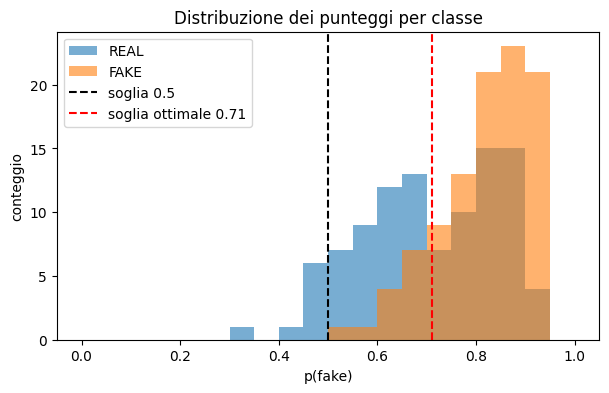

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# 1) Raccogli p(fake) su set BILANCIATO
scores, labels = [], []
for folder, label in [(f"{FF}/Original", 0), (f"{FF}/Deepfakes", 1)]:
    for p in sample(folder, 100):
        pr = veritas_predict(p)
        if pr is None: continue
        scores.append(float(pr[1])); labels.append(label)
scores, labels = np.array(scores), np.array(labels)

# 2) Accuratezza a soglia 0.5 vs soglia ottimale
acc_05 = ((scores > 0.5).astype(int) == labels).mean()
ths = np.linspace(0.3, 0.95, 66)
def bal_acc(th):
    pred = (scores > th).astype(int)
    tpr = pred[labels == 1].mean()           # fake riconosciuti fake
    tnr = (1 - pred[labels == 0]).mean()     # real riconosciuti real
    return (tpr + tnr) / 2
baccs = [bal_acc(t) for t in ths]
i = int(np.argmax(baccs)); best_th = ths[i]

print(f"AUC = {roc_auc_score(labels, scores):.3f}")
print(f"Accuratezza @0.5            = {acc_05:.1%}   (collassa su 'fake')")
print(f"Balanced acc @soglia {best_th:.2f}  = {baccs[i]:.1%}")
print(f"   real corretti: {(scores[labels==0] <= best_th).mean():.1%} | "
      f"fake corretti: {(scores[labels==1] > best_th).mean():.1%}")

# 3) Istogramma: la prova visiva
plt.figure(figsize=(7,4))
plt.hist(scores[labels==0], bins=20, range=(0,1), alpha=0.6, label='REAL')
plt.hist(scores[labels==1], bins=20, range=(0,1), alpha=0.6, label='FAKE')
plt.axvline(0.5, color='k', ls='--', label='soglia 0.5')
plt.axvline(best_th, color='r', ls='--', label=f'soglia ottimale {best_th:.2f}')
plt.xlabel('p(fake)'); plt.ylabel('conteggio'); plt.legend()
plt.title('Distribuzione dei punteggi per classe'); plt.show()

# TEST

In [46]:
import os, random, subprocess, tempfile
from PIL import Image

VALID_IMG_EXT = ('.png', '.jpg', '.jpeg', '.bmp')

def _list_images(root):
    out = []
    for dp, _, fs in os.walk(root):
        out += [os.path.join(dp, f) for f in fs if f.lower().endswith(VALID_IMG_EXT)]
    return sorted(out)

def _save_rgb_png(src, dst):
    try:
        Image.open(src).convert("RGB").save(dst); return True
    except Exception as e:
        print(f"  ⚠️ skip {src}: {e}"); return False

def build_original_split(real_src, fake_src, dataset_path, n_per_class=None, seed=42):
    real, fake = _list_images(real_src), _list_images(fake_src)
    idx = list(range(min(len(real), len(fake)))); random.Random(seed).shuffle(idx)
    if n_per_class is not None: idx = idx[:n_per_class]
    ro = os.path.join(dataset_path, "real_original"); fo = os.path.join(dataset_path, "fake_original")
    os.makedirs(ro, exist_ok=True); os.makedirs(fo, exist_ok=True)
    n = 0
    for k in idx:
        rp = os.path.join(ro, f"real_{n:05d}.png"); fp = os.path.join(fo, f"fake_{n:05d}.png")
        if _save_rgb_png(real[k], rp) and _save_rgb_png(fake[k], fp): n += 1
        else:
            for x in (rp, fp):
                if os.path.exists(x): os.remove(x)
    print(f"✅ {n} coppie in real_original/fake_original")

def _jpegai_run(cmd, jpegai_dir, env="jpeg_ai_vm"):
    r = subprocess.run(["conda","run","-n",env]+cmd, cwd=jpegai_dir, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"JPEG AI fallito:\n{r.stderr[-1500:]}")

def compress_image_jpegai(src, out_png, bpp, jpegai_dir, profile="base", stream_dir="/content/jpegai_streams"):
    os.makedirs(stream_dir, exist_ok=True)
    cfg = ["cfg/tools_off.json", f"cfg/profiles/{profile}.json"]
    stream = os.path.join(stream_dir, os.path.splitext(os.path.basename(src))[0] + f"_{bpp}.bin")
    try:
        _jpegai_run(["python","-m","src.reco.coders.encoder", src, stream, "-r", out_png,
                     "--set_target_bpp", str(int(round(bpp*100))), "--cfg", *cfg], jpegai_dir)
    finally:
        if os.path.exists(stream): os.remove(stream)

def compress_dataset_jpegai(dataset_path, bpp_list, jpegai_dir):
    for cls in ("real", "fake"):
        sd = os.path.join(dataset_path, f"{cls}_original")
        imgs = [f for f in sorted(os.listdir(sd)) if f.lower().endswith(VALID_IMG_EXT)]
        print(f"=== {cls}: {len(imgs)} immagini ===")
        for bpp in bpp_list:
            od = os.path.join(dataset_path, f"{cls}_bpp{bpp}"); os.makedirs(od, exist_ok=True)
            print(f"  bpp={bpp}")
            for fn in imgs:
                out = os.path.join(od, os.path.splitext(fn)[0] + ".png")
                if os.path.exists(out): continue          # ripartibile
                try: compress_image_jpegai(os.path.join(sd, fn), out, bpp, jpegai_dir)
                except Exception as e: print(f"    ❌ {fn}: {e}")
    print("✅ Compressione completata.")
print("✅ Funzioni pronte")

✅ Funzioni pronte


In [48]:
import os
os.environ['PATH'] = '/content/miniconda/bin:' + os.environ['PATH']   # assicura conda sul PATH

DATASET_PATH = "/content/drive/MyDrive/Deepfake_Dataset"
JPEGAI_DIR   = "/content/jpeg-ai-reference-software"
BPP_LIST     = [0.12, 0.25, 0.50, 0.75]
FF           = "/content/ff/FF++C32-Frames"

build_original_split(f"{FF}/Original", f"{FF}/Deepfakes", DATASET_PATH, n_per_class=25)
compress_dataset_jpegai(DATASET_PATH, BPP_LIST, JPEGAI_DIR)

✅ 25 coppie in real_original/fake_original
=== real: 25 immagini ===
  bpp=0.12
  bpp=0.25
  bpp=0.5
  bpp=0.75
=== fake: 25 immagini ===
  bpp=0.12
  bpp=0.25
  bpp=0.5
  bpp=0.75
✅ Compressione completata.


In [1]:
import numpy as np, os
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

def auc_for_condition(dataset_path, suffix):
    scores, labels = [], []
    for cls, label in [("real", 0), ("fake", 1)]:
        d = os.path.join(dataset_path, f"{cls}_{suffix}")
        if not os.path.isdir(d): continue
        for f in sorted(os.listdir(d)):
            pr = veritas_predict(os.path.join(d, f))
            if pr is None: continue
            scores.append(float(pr[1])); labels.append(label)
    if len(set(labels)) < 2: return None, len(labels)
    return roc_auc_score(np.array(labels), np.array(scores)), len(labels)

conds = ["original"] + [f"bpp{b}" for b in BPP_LIST]
aucs = []
print("CONDIZIONE     AUC     n")
for suf in conds:
    a, n = auc_for_condition(DATASET_PATH, suf); aucs.append(a)
    print(f"{suf:12s}  {None if a is None else round(a,3)}   {n}")

plt.figure(figsize=(7,4))
plt.axhline(aucs[0], color='g', ls='--', label=f'originale AUC={aucs[0]:.3f}')
plt.plot(BPP_LIST, aucs[1:], 'o-', label='compresso')
plt.axhline(0.5, color='k', ls=':', label='caso (0.5)')
plt.xlabel('bpp'); plt.ylabel('AUC'); plt.title('Degradation curve — Veritas vs JPEG AI')
plt.legend(); plt.show()

NameError: name 'BPP_LIST' is not defined

# Network

In [ ]:
# -- SEZIONE 5: Network --
from network import get_model

# Inizializza il modello e spostalo sulla GPU (se disponibile)
model = get_model(DEVICE)
print("✅ Modello caricato e pronto sulla GPU!")

# Test veloce: passiamo un batch casuale per vedere se il modello risponde
dummy_input = torch.randn(4, 3, 256, 256).to(DEVICE)
output = model(dummy_input)
print(f"✅ Inferenza di test completata! Output shape: {output.shape}")
# Dovrebbe stampare torch.Size([4, 2])